In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [19]:
orders = pd.read_csv(r"..\Blinkit_datasets\blinkit_orders.csv")
orders_items = pd.read_csv(r"..\Blinkit_datasets\blinkit_order_items.csv")

In [20]:
orders.columns

Index(['order_id', 'customer_id', 'order_date', 'promised_delivery_time',
       'actual_delivery_time', 'delivery_status', 'order_total',
       'payment_method', 'delivery_partner_id', 'store_id'],
      dtype='object')

In [21]:
orders_items.columns

Index(['order_id', 'product_id', 'quantity', 'unit_price'], dtype='object')

In [22]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                5000 non-null   int64  
 1   customer_id             5000 non-null   int64  
 2   order_date              5000 non-null   object 
 3   promised_delivery_time  5000 non-null   object 
 4   actual_delivery_time    5000 non-null   object 
 5   delivery_status         5000 non-null   object 
 6   order_total             5000 non-null   float64
 7   payment_method          5000 non-null   object 
 8   delivery_partner_id     5000 non-null   int64  
 9   store_id                5000 non-null   int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 390.8+ KB


In [23]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['promised_delivery_time'] = pd.to_datetime(orders['promised_delivery_time'])
orders['actual_delivery_time'] = pd.to_datetime(orders['actual_delivery_time'])

# Blinkit orders analysis

# --------------------------------------------------------------------------------------

# Monthly sales revenue

In [24]:
orders['order_month'] = orders['order_date'].dt.month_name()

month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

orders['order_month'] = pd.Categorical(
    orders['order_month'],
    categories=month_order,
    ordered=True
)

C:\Users\PAVANA HEBBAR\AppData\Local\Temp\ipykernel_26844\1643188777.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = orders.groupby('order_month', as_index=False)['order_total'].sum()


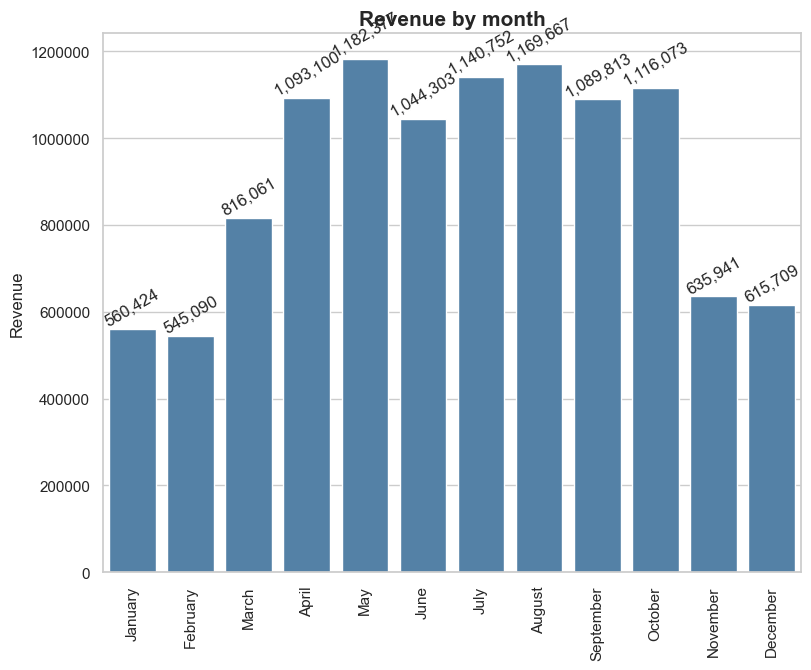

In [25]:
df = orders.groupby('order_month', as_index=False)['order_total'].sum()

fig, ax = plt.subplots(figsize=(9,7))


sns.barplot(data = df, x = 'order_month', y = 'order_total', ax = ax, color='steelblue')

plt.title('Revenue by month', fontsize=15, fontweight='bold')
plt.xlabel('')
plt.ylabel('Revenue')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=90)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', rotation=30)


plt.show()

- Monthly revenue fluctuates throughout the analysis period, indicating variations in customer demand across different months. Months with higher revenue represent stronger sales performance, while lower-revenue months may reflect seasonal demand or reduced purchasing activity.

# Which day of the week has more orders

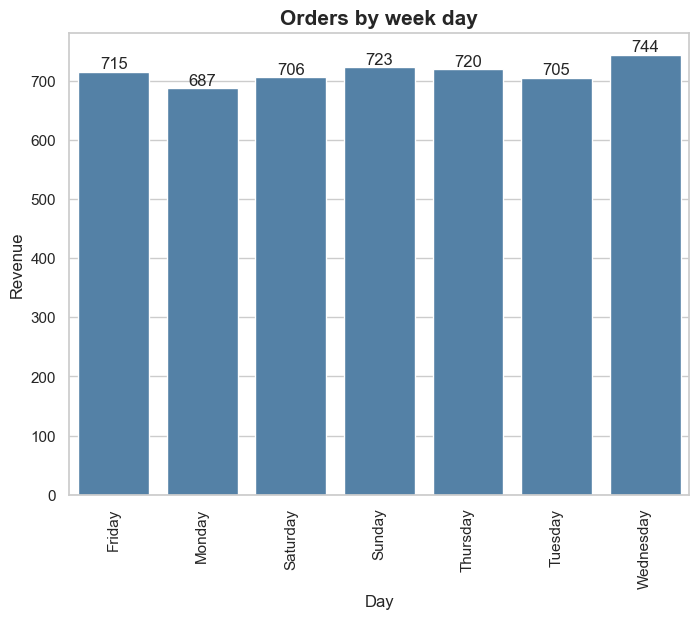

In [26]:
orders['day'] = orders['order_date'].dt.day_name()
df = orders.groupby('day', as_index=False)['order_id'].count()

fig, ax = plt.subplots(figsize=(8, 6))


sns.barplot(data = df, x = 'day', y = 'order_id', ax = ax, color='steelblue')

plt.title('Orders by week day', fontsize=15, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Revenue')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=90)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')


plt.show()

- Order volume remains fairly consistent across all weekdays, with Wednesday recording the highest number of orders (744) and Monday the lowest (687). This indicates stable customer demand throughout the week without significant weekday or weekend spikes.

# Busiest hour of the day

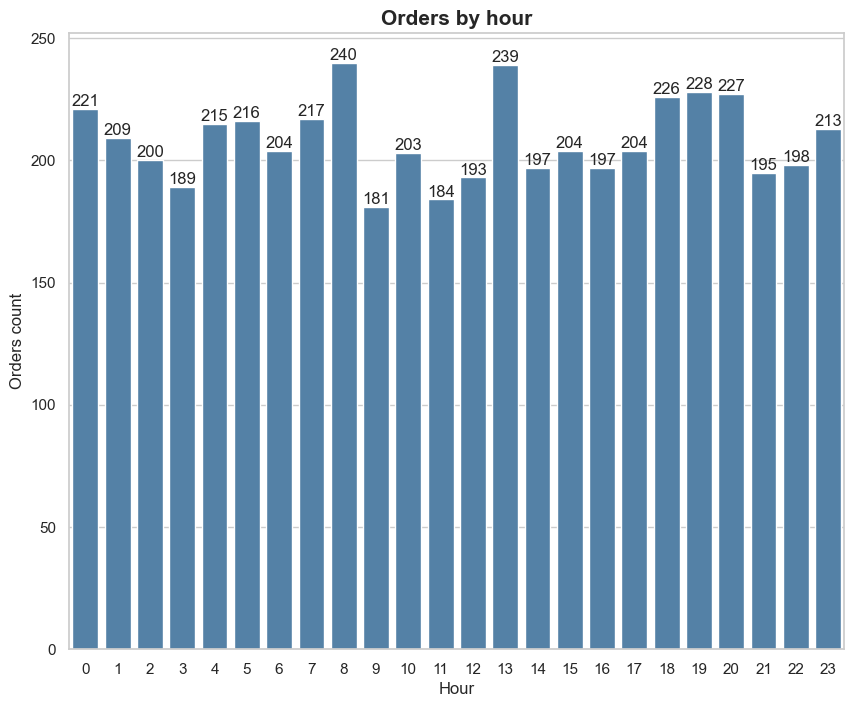

In [27]:
Hour = pd.DataFrame()
Hour = (orders.groupby(orders['order_date'].dt.hour.rename('hour'))['order_id'].count().reset_index())
fig, ax = plt.subplots(figsize=(10, 8))

sns.barplot(data = Hour, x = 'hour', y = 'order_id', color = 'steelblue', ax = ax)

plt.title('Orders by hour', fontsize=15, fontweight='bold')
plt.xlabel('Hour')
plt.ylabel('Orders count')
plt.ticklabel_format(style='plain', axis='y')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()

- Customer ordering activity is distributed throughout the day, with noticeable peaks around 8 AM, 1 PM, and 6–8 PM. These peak periods represent the highest operational demand and should be prioritized for staffing and delivery resource allocation.

# Monthly revenue growth trend

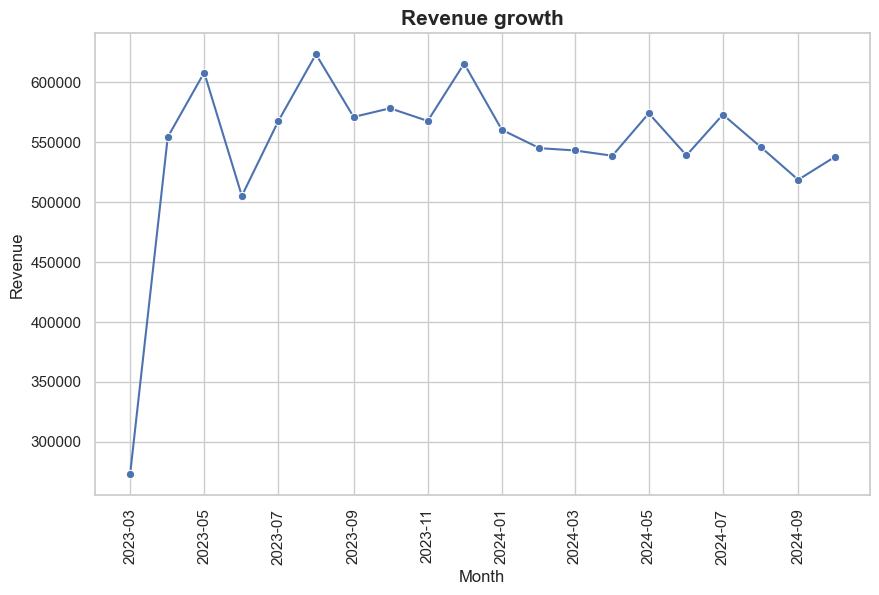

In [28]:
monthly_revenue = pd.DataFrame()
monthly_revenue['year_month'] = orders['order_date'].dt.to_period('M').dt.to_timestamp()
monthly_revenue['order_total'] = orders['order_total']
monthly_revenue = monthly_revenue[~(monthly_revenue['year_month'] == '2024-11-01 00:00:00')]

monthly_revenue_df = monthly_revenue.groupby('year_month', as_index = False)['order_total'].sum()

fig, ax = plt.subplots(figsize=(10,6))

sns.lineplot(data = monthly_revenue_df, x = 'year_month', y = 'order_total', marker = 'o', ax = ax)

plt.title('Revenue growth', fontsize=15, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=90)

plt.show()

- Revenue shows strong growth during the initial months before stabilizing around ₹5.4–₹6.2 lakh per month. The relatively stable trend after mid-2023 suggests consistent business performance with only minor month-to-month fluctuations.

# Monthly orders count

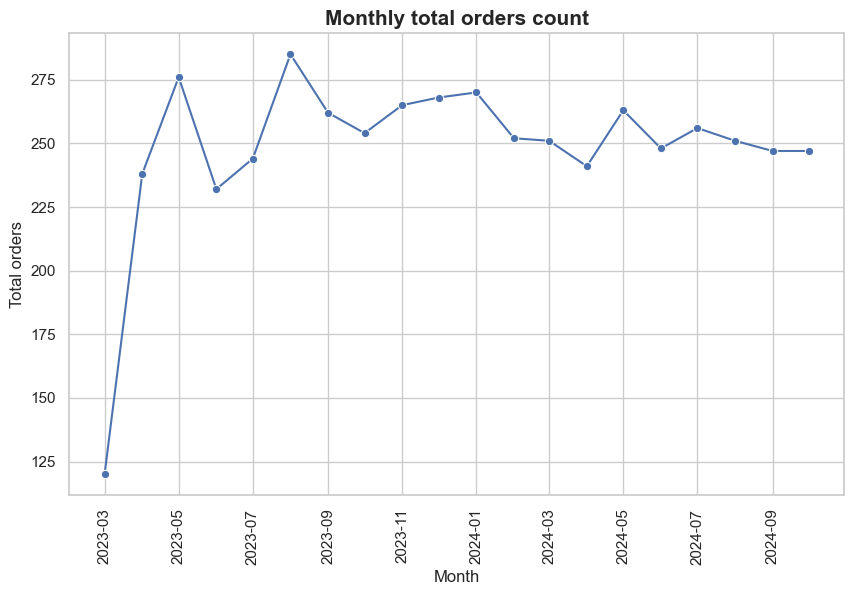

In [29]:
monthly_orders = pd.DataFrame()
monthly_orders['month_period'] = orders['order_date'].dt.to_period('M').dt.to_timestamp()
monthly_orders['order_id'] = orders['order_id']
monthly_orders = monthly_orders[~(monthly_orders['month_period'] == '2024-11-01 00:00:00')]

monthly_orders_df = monthly_orders.groupby('month_period', as_index = False)['order_id'].count()

fig, ax = plt.subplots(figsize=(10,6))

sns.lineplot(data = monthly_orders_df, x = 'month_period', y = 'order_id', marker = 'o', ax = ax)

plt.title('Monthly total orders count', fontsize=15, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total orders')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=90)
ax.ticklabel_format(style='plain', axis='y')

plt.show()


- Monthly order volume increased during the initial months before stabilizing with moderate fluctuations, indicating relatively consistent customer demand over time

# Order amount distribution

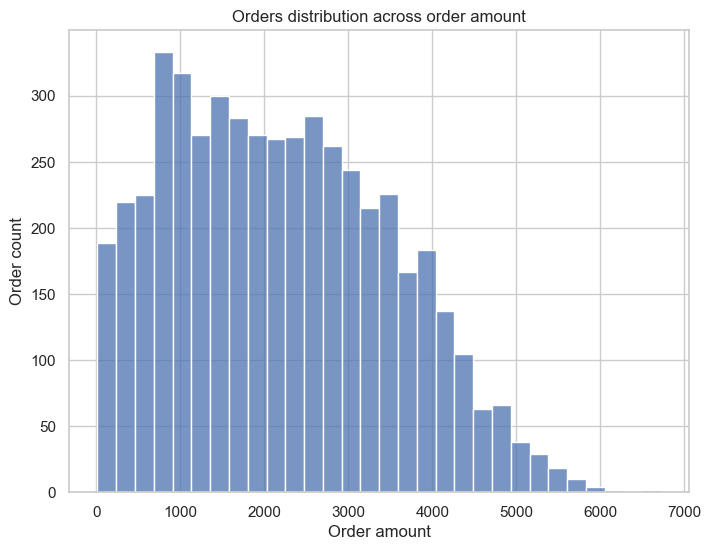

In [30]:
plt.figure(figsize=(8,6))
sns.histplot(data = orders['order_total'], bins = 30, kde = False)

plt.title('Orders distribution across order amount')
plt.xlabel('Order amount')
plt.ylabel('Order count')

plt.show()

- Most orders fall between ₹800 and ₹3,500, while high-value orders above ₹5,000 are relatively uncommon. The distribution is positively skewed, indicating that the majority of customers place moderate-value orders with only a small proportion making premium purchases.

# Monthly average order value trend

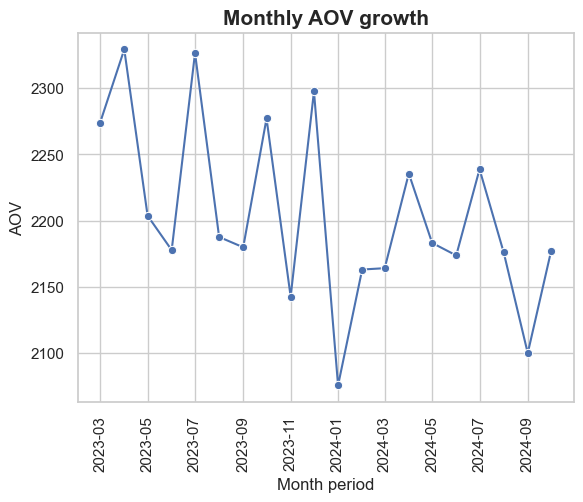

In [31]:
monthly_aov = pd.DataFrame()
monthly_aov['month_period'] = orders['order_date'].dt.to_period('M').dt.to_timestamp()
monthly_aov['order_id'] = orders['order_id']
monthly_aov['order_total'] = orders['order_total']
monthly_aov = monthly_aov[~(monthly_aov['month_period'] == '2024-11-01 00:00:00')]

monthly = monthly_aov.groupby('month_period',as_index=False).agg(Revenue=('order_total','sum'),Orders=('order_id','count'))

monthly['AOV'] = (monthly['Revenue'] /monthly['Orders'])

sns.lineplot(data = monthly, x = 'month_period', y = 'AOV', marker = 'o')

plt.title('Monthly AOV growth', fontsize=15, fontweight='bold')
plt.xlabel('Month period')
plt.ylabel('AOV')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=90)

plt.show()

- Average Order Value varies across the analysis period, suggesting that both customer spending per order and order volume influence overall revenue performance.

# Month-over-month revenue growth

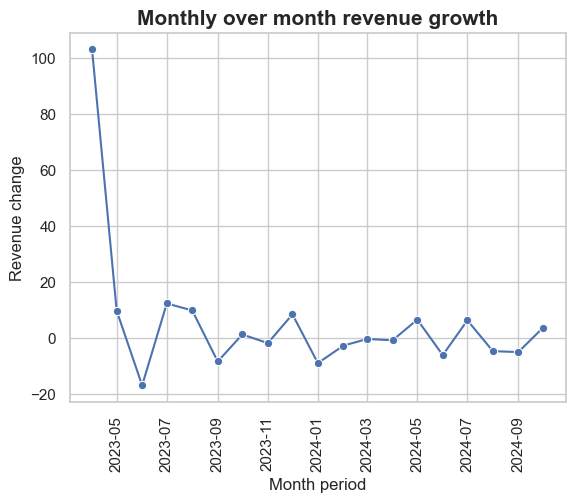

In [32]:
revenue_growth = pd.DataFrame()
revenue_growth['month_period'] = orders['order_date'].dt.to_period('M').dt.to_timestamp()
revenue_growth['order_total'] = orders['order_total']
revenue_growth = revenue_growth[~(revenue_growth['month_period'] == '2024-11-01 00:00:00')]

revenue_mom = revenue_growth.groupby('month_period', as_index=False)['order_total'].sum()

revenue_mom['mom_growth'] = revenue_mom['order_total'].pct_change() * 100

sns.lineplot(data = revenue_mom, x = 'month_period', y = 'mom_growth', marker = 'o')

plt.title('Monthly over month revenue growth', fontsize=15, fontweight='bold')
plt.xlabel('Month period')
plt.ylabel('Revenue change')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=90)

plt.show()

- Revenue growth was exceptionally high during the initial growth phase, after which month-over-month changes remained relatively small. This indicates that the business transitioned from rapid expansion to a more stable and predictable growth pattern.

# Revenue by payment method

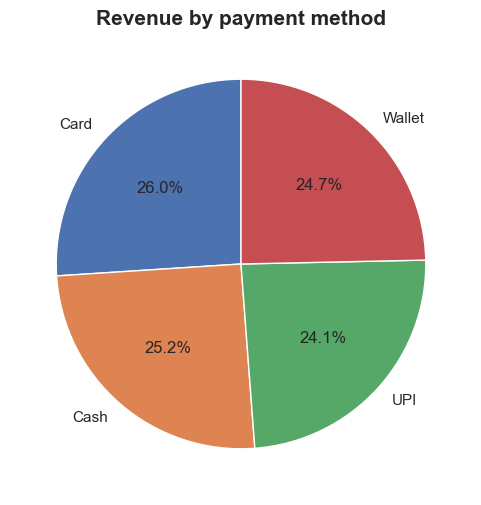

In [33]:
payment_method = orders.groupby('payment_method', as_index=True)['order_total'].sum()

fig, ax = plt.subplots(figsize=(6, 6))

payment_method.plot(kind = 'pie', autopct = '%1.1f%%', startangle = 90)

plt.ylabel('')
plt.title('Revenue by payment method', fontsize=15, fontweight='bold')



plt.show()

- Revenue contribution is almost evenly distributed across all payment methods, with Card payments contributing a slightly higher share (26%). This balanced distribution suggests customers are comfortable using multiple payment options rather than relying on a single preferred method.

# Total orders by payment method

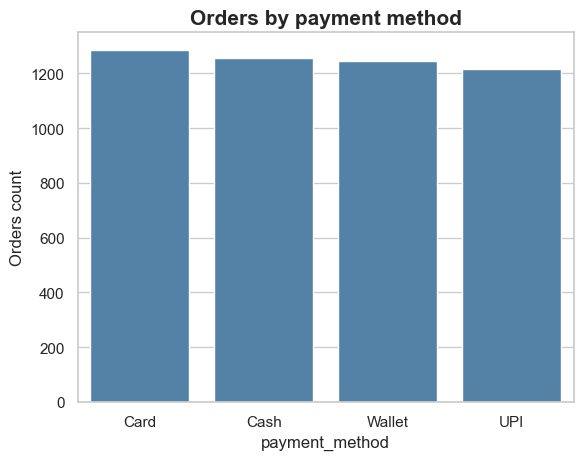

In [34]:
payment_orders = (orders.groupby('payment_method', as_index=False)['order_id'].count().sort_values(by = 'order_id', ascending=False))

sns.barplot(data = payment_orders, x = 'payment_method', y = 'order_id', color = 'steelblue')

plt.title('Orders by payment method', fontsize=15, fontweight='bold')
plt.xlabel('payment_method')
plt.ylabel('Orders count')
plt.ticklabel_format(style='plain', axis='y')

plt.show()

- Order volume is evenly distributed across all payment methods, indicating that customer payment preferences are well balanced. No single payment option dominates transaction volume, highlighting the importance of supporting multiple payment methods.

# Overall Business Insights

Monthly revenue exhibited moderate fluctuations throughout the analysis period, reflecting variations in customer demand and purchasing activity. Average Order Value also varied across months, suggesting that both customer spending per order and order volume influenced revenue trends. Customer demand remained fairly consistent across weekdays, with predictable ordering peaks during specific hours of the day, supporting operational planning and workforce allocation. Finally, the balanced distribution of payment methods indicates that customers actively use multiple payment options without strong dependence on any single payment method